# Visualize reward sidecars (joint dataset)

Load and plot per-episode `reward / returns / advantage / AWR-weight` sidecars
written by `scripts/annotate_rewards_joint.py` for a **single joint** LeRobot
dataset (produced by `scripts/convert_raiden_to_lerobot_joint.py`).

Per-episode optimality is read from `meta/optimality.jsonl` so we colour-code
trajectories without juggling three separate repos.

Sliders at the bottom let you live-tweak `BETA`, `WEIGHT_QUANTILE`, and
`WEIGHT_CUTOFF` to preview which samples would survive the training-time filter.

In [7]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from lerobot.common.constants import HF_LEROBOT_HOME

# ── Configuration ────────────────────────────────────────────────
REPO_ID         = "memmelma/swb_joint"
PREFIX          = "success"
USE_DELTA       = False       # use delta reward variant (r[t+1]-r[t])
BETA            = 2.0        # AWR temperature: w = exp(adv / beta)
WEIGHT_QUANTILE = 0.8        # drop bottom q*100% of weights (None = off). 0.8 keeps top 20%.
WEIGHT_CUTOFF   = None       # drop weights below this absolute value (None = off)
N_TRAJS         = None       # cap trajectories per group (None = all)
LEROBOT_HOME    = None       # override $HF_LEROBOT_HOME (None = use default)

OPT_COLORS = {"failure": "red", "suboptimal": "gold", "optimal": "green"}

# ── Resolve paths ───────────────────────────────────────────────
base = Path(LEROBOT_HOME) if LEROBOT_HOME is not None else HF_LEROBOT_HOME
root = Path(base) / REPO_ID
rewards_root = root / "meta" / "rewards"
opt_path = root / "meta" / "optimality.jsonl"
if not opt_path.exists():
    raise FileNotFoundError(
        f"{opt_path} not found. This notebook expects a joint dataset "
        f"produced by convert_raiden_to_lerobot_joint.py."
    )
optimality = {int(r['episode_index']): r['optimality'] for r in (json.loads(l) for l in opt_path.read_text().splitlines() if l.strip())}
print(f"Joint dataset {REPO_ID} has {len(optimality)} episodes")
print("  optimality counts:", {k: sum(1 for v in optimality.values() if v == k) for k in OPT_COLORS})

if USE_DELTA:
    reward_dir    = rewards_root / f"{PREFIX}_delta"
    returns_dir   = rewards_root / f"{PREFIX}_delta_returns"
    advantage_dir = rewards_root / f"{PREFIX}_delta_advantage"
else:
    reward_dir    = rewards_root / f"{PREFIX}_reward"
    returns_dir   = rewards_root / f"{PREFIX}_returns"
    advantage_dir = rewards_root / f"{PREFIX}_advantage"

if not reward_dir.exists():
    raise FileNotFoundError(f"{reward_dir} not found. Run scripts/annotate_rewards_joint.py first.")

# ── Load instruction (used at training time if override_prompt_from_reward) ────
reward_cfg_path = rewards_root / f"{PREFIX}_reward" / "config.json"
if reward_cfg_path.exists():
    reward_cfg = json.loads(reward_cfg_path.read_text())
    print(f"  reward instruction: {reward_cfg.get('reference_instruction', '<none>')!r}")
    print(f"  reward model     : {reward_cfg.get('reward_model')}")

# ── Load sidecars ─────────────────────────────────────────────────
def load_episode(d: Path, ep: int) -> np.ndarray:
    p = d / f"episode_{ep:06d}.npy"
    return np.load(p) if p.exists() else None

rewards, returns, advantages, labels, colors, ep_indices = [], [], [], [], [], []
per_group_count = {k: 0 for k in OPT_COLORS}
for ep_idx in sorted(optimality):
    opt = optimality[ep_idx]
    if N_TRAJS is not None and per_group_count[opt] >= N_TRAJS:
        continue
    r = load_episode(reward_dir, ep_idx)
    if r is None:
        continue
    rewards.append(r)
    returns.append(load_episode(returns_dir, ep_idx) if returns_dir.exists() else np.full_like(r, np.nan))
    advantages.append(load_episode(advantage_dir, ep_idx) if advantage_dir.exists() else np.full_like(r, np.nan))
    labels.append(opt)
    colors.append(OPT_COLORS[opt])
    ep_indices.append(ep_idx)
    per_group_count[opt] += 1

print(f"Loaded {len(rewards)} episodes")

Joint dataset memmelma/swb_joint has 65 episodes
  optimality counts: {'failure': 0, 'suboptimal': 0, 'optimal': 65}
  reward instruction: ''
  reward model     : success
Loaded 65 episodes


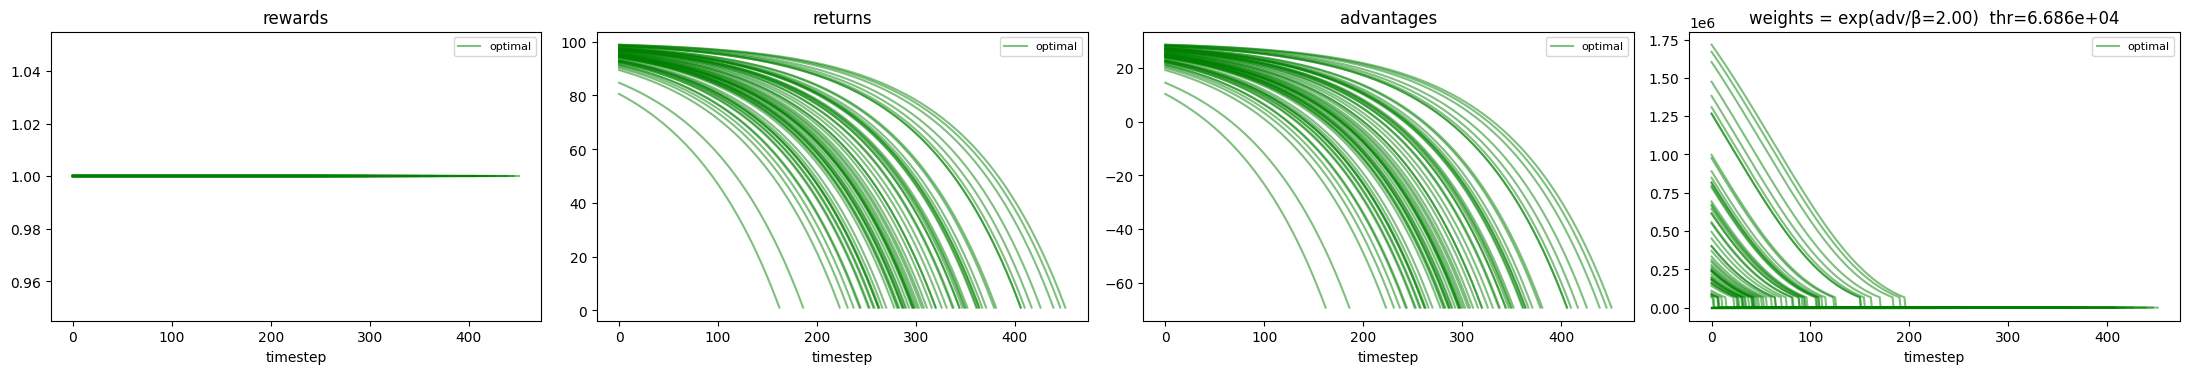

Survival after quantile+cutoff filter:
     failure:       0 / 0        (0.0%)
  suboptimal:       0 / 0        (0.0%)
     optimal:    4154 / 20530    (20.2%)


In [8]:
# ── AWR weight + filter helpers ──────────────────────────────────────────
def adv_to_weights(adv: np.ndarray, beta: float, clip: float = 100.0) -> np.ndarray:
    return np.exp(np.clip(adv / max(beta, 1e-6), -clip, clip))

def compute_threshold(all_weights: np.ndarray, quantile, cutoff) -> float:
    th = -np.inf
    if quantile is not None:
        th = max(th, float(np.quantile(all_weights, quantile)))
    if cutoff is not None:
        th = max(th, float(cutoff))
    return th

def apply_threshold(w: np.ndarray, th: float) -> np.ndarray:
    if not np.isfinite(th):
        return w
    out = w.copy()
    out[out < th] = 0.0
    return out

def stats_per_group(weights_per_ep, th):
    rows = {}
    for lbl in OPT_COLORS:
        kept = total = 0
        for w, l in zip(weights_per_ep, labels):
            if l != lbl:
                continue
            total += w.size
            kept += int(np.sum(w >= th)) if np.isfinite(th) else int(w.size)
        rows[lbl] = (kept, total, (kept / total) if total else 0.0)
    return rows

def plot_signals(beta, quantile, cutoff):
    valid_advs = [a for a in advantages if a is not None and not np.any(np.isnan(a))]
    if not valid_advs:
        print("No advantage data available.")
        return
    weights_per_ep = [adv_to_weights(a, beta) for a in advantages]
    all_w = np.concatenate([adv_to_weights(a, beta) for a in valid_advs])
    th = compute_threshold(all_w, quantile, cutoff)

    cols = ["rewards", "returns", "advantages", "weights"]
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    seen = {}
    for i, lbl in enumerate(labels):
        axes[0].plot(rewards[i],    alpha=0.5, color=colors[i], label=lbl if lbl not in seen else "_")
        axes[1].plot(returns[i],    alpha=0.5, color=colors[i], label=lbl if lbl not in seen else "_")
        axes[2].plot(advantages[i], alpha=0.5, color=colors[i], label=lbl if lbl not in seen else "_")
        axes[3].plot(apply_threshold(weights_per_ep[i], th), alpha=0.5, color=colors[i], label=lbl if lbl not in seen else "_")
        seen[lbl] = True
    titles = ["rewards", "returns", "advantages",
              f"weights = exp(adv/β={beta:.2f})  thr={th:.4g}" if np.isfinite(th) else f"weights = exp(adv/β={beta:.2f})"]
    for ax, t in zip(axes, titles):
        ax.set_title(t)
        ax.set_xlabel("timestep")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # per-group survival
    rows = stats_per_group(weights_per_ep, th)
    print("Survival after quantile+cutoff filter:")
    for lbl, (kept, total, frac) in rows.items():
        print(f"  {lbl:>10s}: {kept:>7d} / {total:<7d}  ({frac:.1%})")

plot_signals(BETA, WEIGHT_QUANTILE, WEIGHT_CUTOFF)

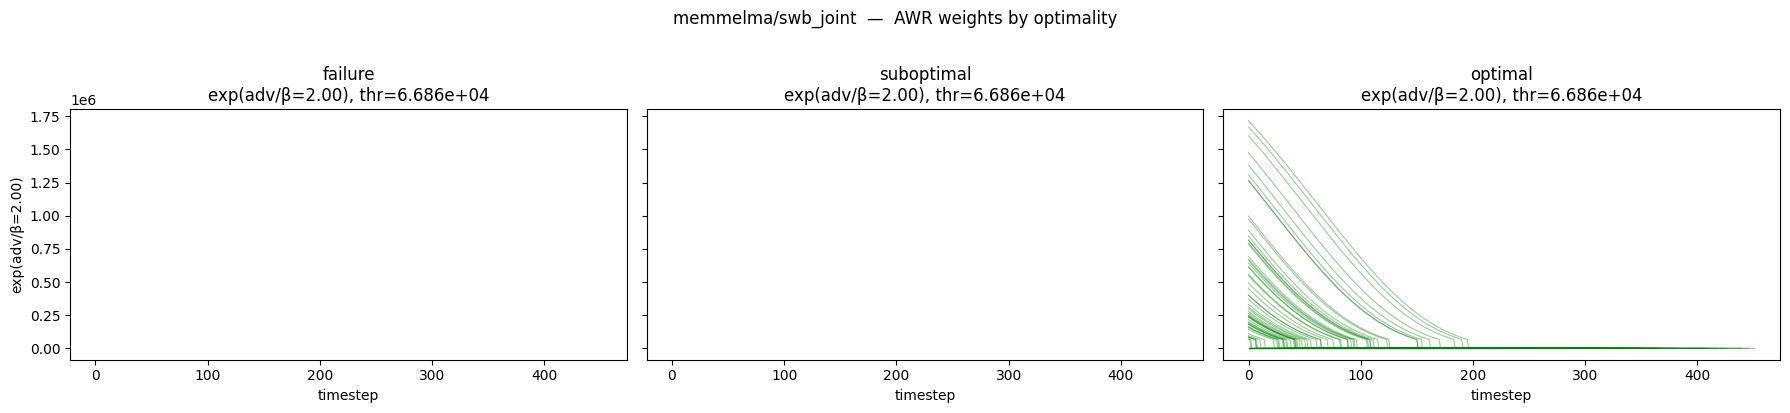

In [9]:
# ── Per-optimality breakdown of AWR weights ────────────────────────────────────
def plot_per_group(beta, quantile, cutoff):
    valid_advs = [a for a in advantages if a is not None and not np.any(np.isnan(a))]
    if not valid_advs:
        print("No advantage data available.")
        return
    all_w = np.concatenate([adv_to_weights(a, beta) for a in valid_advs])
    th = compute_threshold(all_w, quantile, cutoff)
    groups = list(OPT_COLORS)
    fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4), sharey=True, sharex=True)
    if len(groups) == 1:
        axes = [axes]
    for ax, grp in zip(axes, groups):
        for w, lbl in zip([adv_to_weights(a, beta) for a in advantages], labels):
            if lbl != grp:
                continue
            ax.plot(apply_threshold(w, th), alpha=0.4, color=OPT_COLORS[grp], linewidth=0.8)
        ax.set_title(f"{grp}\nexp(adv/β={beta:.2f}), thr={th:.4g}")
        ax.set_xlabel("timestep")
    axes[0].set_ylabel(f"exp(adv/β={beta:.2f})")
    plt.suptitle(f"{REPO_ID}  —  AWR weights by optimality", y=1.02)
    plt.tight_layout()
    plt.show()

plot_per_group(BETA, WEIGHT_QUANTILE, WEIGHT_CUTOFF)

In [10]:
# ── Interactive sliders ────────────────────────────────────────────────────
# Drag the sliders to live-tune beta / weight_quantile / weight_cutoff.
# Settings shown here mirror the training-time data filter in
# src/openpi/training/rewards.py:RewardLookup.
import ipywidgets as widgets
from IPython.display import display

beta_w     = widgets.FloatSlider(value=BETA, min=0.1, max=10.0, step=0.1, description="beta")
quantile_w = widgets.FloatSlider(value=WEIGHT_QUANTILE or 0.0, min=0.0, max=0.99, step=0.01, description="quantile")
cutoff_w   = widgets.FloatText(value=WEIGHT_CUTOFF or 0.0, description="cutoff")
use_q_w    = widgets.Checkbox(value=WEIGHT_QUANTILE is not None, description="use quantile")
use_c_w    = widgets.Checkbox(value=WEIGHT_CUTOFF is not None,   description="use cutoff")

ui = widgets.HBox([beta_w, use_q_w, quantile_w, use_c_w, cutoff_w])
out = widgets.Output()

def _refresh(*_):
    with out:
        out.clear_output(wait=True)
        q = quantile_w.value if use_q_w.value else None
        c = cutoff_w.value   if use_c_w.value else None
        plot_signals(beta_w.value, q, c)

for w in (beta_w, quantile_w, cutoff_w, use_q_w, use_c_w):
    w.observe(_refresh, names='value')

display(ui, out)
_refresh()

Output()